In [ ]:
# 1 Basic Regression

In [1]:
#Import the required libraries
import pandas as pd
import os.path as osp

#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Sales Data',index_col='Observation')
data.head()

,Order_Size,Ad_Budget,Male,Distance
Observation,,,,
1,20.77,3975,0,20
2,49.52,10897,0,5
3,66.40,15067,0,4
4,34.43,5898,0,4
5,98.65,24928,0,11


In [2]:
data.describe()

,Order_Size,Ad_Budget,Male,Distance
count,200.000000,200.000000,200.000000,200.000000
mean,56.575000,10489.520000,0.280000,8.320000
std,22.310774,6616.043323,0.450126,4.555366
min,8.550000,-2883.000000,0.000000,1.000000
25%,38.712500,5312.750000,0.000000,5.000000
50%,58.325000,9589.000000,0.000000,7.000000
75%,71.532500,14443.500000,1.000000,10.000000
max,135.300000,36039.000000,1.000000,25.000000


In [4]:
data.dtypes

Order_Size    float64
Ad_Budget       int64
Male            int64
Distance        int64
dtype: object

In [5]:
from sklearn.linear_model import LinearRegression

train_X = data[['Ad_Budget','Distance']].values
train_y = data['Order_Size'].values

reg = LinearRegression().fit(train_X, train_y)

In [6]:
import numpy as np

In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Order_Size ~ Ad_Budget + Distance',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Order_Size   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     178.6
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           5.64e-45
Time:                        19:38:24   Log-Likelihood:                -800.86
No. Observations:                 200   AIC:                             1608.
Df Residuals:                     197   BIC:                             1618.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     26.8988      2.583     10.415      0.0

In [8]:
#Removing Distance because it has value of P-stat is very high
train_X = data[['Ad_Budget']].values
train_y = data['Order_Size'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Order_Size ~ Ad_Budget',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Order_Size   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     357.7
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           3.01e-46
Time:                        19:40:35   Log-Likelihood:                -801.10
No. Observations:                 200   AIC:                             1606.
Df Residuals:                     198   BIC:                             1613.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.1951      1.773     15.904      0.0

In [ ]:
# 2 Bimodal Error

In [11]:
#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Bimodal Error 1',index_col='Obs')
data.head()

,Y,X1,X2
Obs,,,
1,2258,10,25
2,7542,62,27
3,4254,29,33
4,2355,7,58
5,8355,71,37


In [13]:
train_X = data[['X1','X2']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ X1 + X2',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.188e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          4.30e-206
Time:                        19:47:09   Log-Likelihood:                -1394.6
No. Observations:                 200   AIC:                             2795.
Df Residuals:                     197   BIC:                             2805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1159.3613     82.674     14.023      0.0

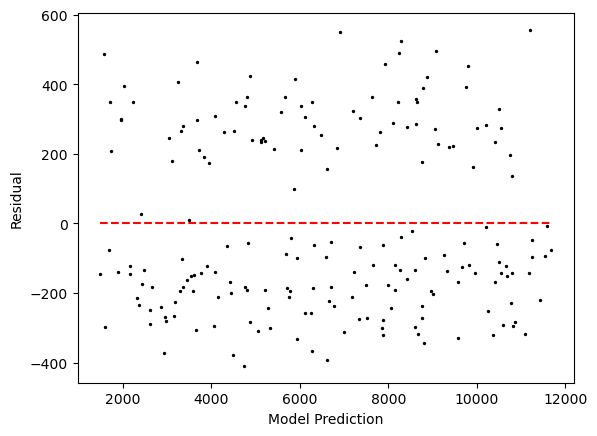

In [14]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# Above is split into two halves. Very odd.

In [ ]:
# Bimodal Error 2

In [15]:
#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Bimodal Error 2',index_col='Obs')
data.head()

,Y,X1,X2,US
Obs,,,,
1,2258,10,25,0
2,7542,62,27,0
3,4254,29,33,0
4,2355,7,58,0
5,8355,71,37,0


In [16]:
train_X = data[['X1','X2', 'US']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ X1 + X2 + US',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.483e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          2.89e-286
Time:                        19:51:44   Log-Likelihood:                -1201.3
No. Observations:                 200   AIC:                             2411.
Df Residuals:                     196   BIC:                             2424.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1014.1135     31.820     31.870      0.0

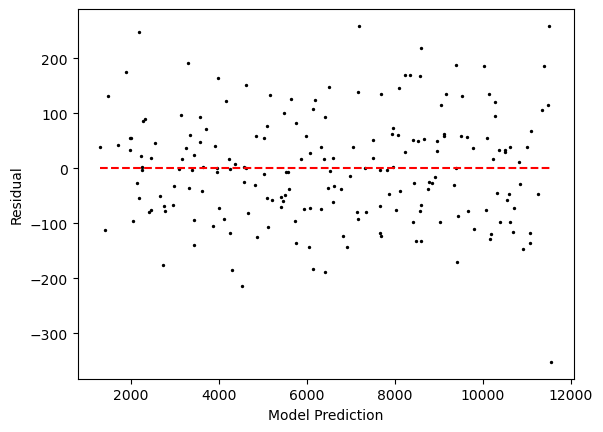

In [17]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# 4 Non-Normal Errors 

In [18]:
#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Nonlinear',index_col='Obs')
data.head()

,Y,X1,X1Squared
Obs,,,
1,448.862636,6,36
2,560.644994,1,1
3,538.691453,1,1
4,379.603825,6,36
5,331.434588,7,49


In [21]:
train_X = data[['X1']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ X1',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     288.3
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           2.73e-40
Time:                        20:07:17   Log-Likelihood:                -1148.3
No. Observations:                 197   AIC:                             2301.
Df Residuals:                     195   BIC:                             2307.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    622.1634     13.176     47.219      0.0

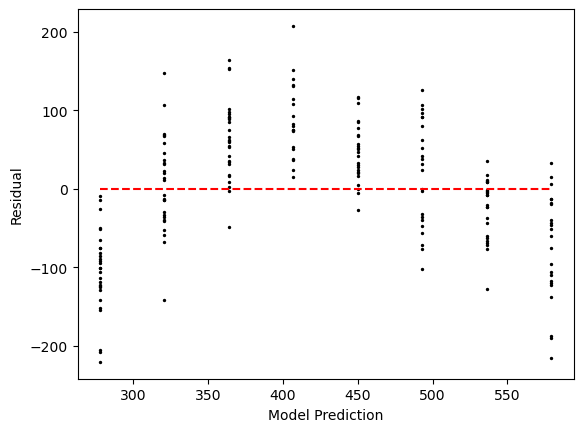

In [22]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [19]:
train_X = data[['X1','X1Squared']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ X1 + X1Squared',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     422.1
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           2.20e-71
Time:                        20:04:25   Log-Likelihood:                -1072.5
No. Observations:                 197   AIC:                             2151.
Df Residuals:                     194   BIC:                             2161.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    419.2591     16.245     25.808      0.0

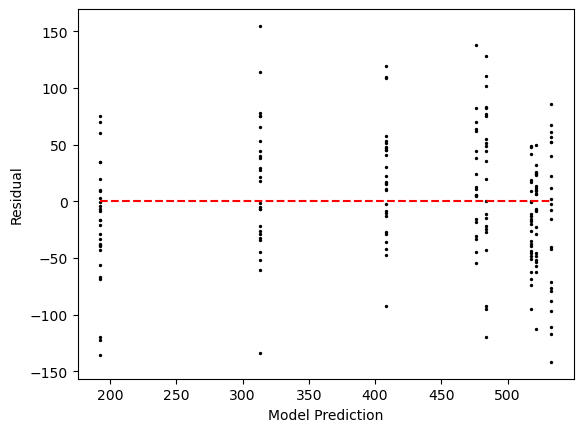

In [20]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# Outliers

In [35]:
#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Outliers',index_col='Obs')
data.head()

,Y,X,Outlier
Obs,,,
1,70,3,2
2,103,7,4
3,143,7,4
4,113,8,3
5,117,3,2


In [36]:
train_X = data[['X','Outlier']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ X + Outlier',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     58.67
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.77e-17
Time:                        20:39:17   Log-Likelihood:                -432.04
No. Observations:                 101   AIC:                             870.1
Df Residuals:                      98   BIC:                             877.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     86.4067      4.088     21.139      0.0

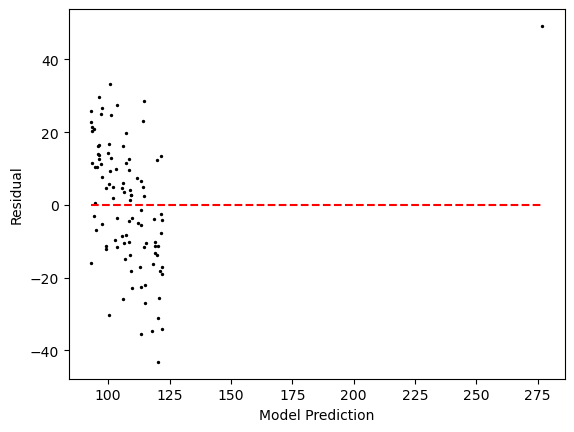

In [37]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

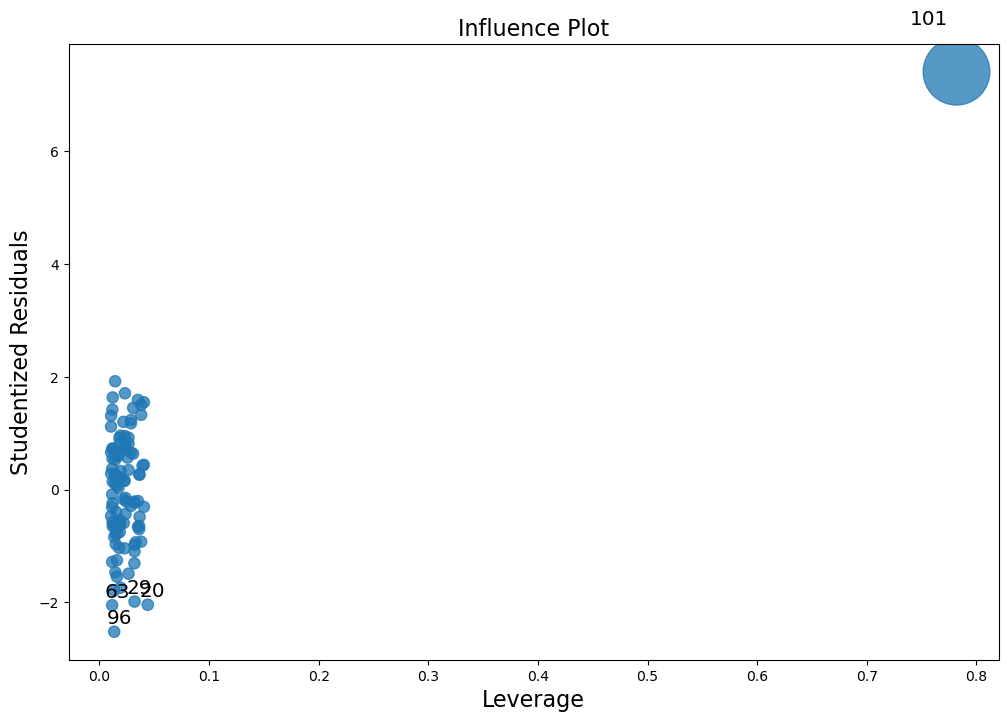

In [38]:
#In a similar fashion to how the QQ plot was built, this plot can be generated.
fig, ax = plt.subplots(figsize=(12,8))
fig = sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.show()

In [ ]:
# Heteroskedasticity

In [27]:
#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Heteroskedasticity',index_col='Obs')
data.head()

,Y,X1,X2
Obs,,,
1,4084,38,22
2,4828,45,24
3,10304,98,21
4,5379,53,18
5,1670,14,27


In [28]:
train_X = data[['X1','X2']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ X1 + X2',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.532e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          8.06e-145
Time:                        20:26:18   Log-Likelihood:                -593.82
No. Observations:                 100   AIC:                             1194.
Df Residuals:                      97   BIC:                             1201.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     93.1518     62.684      1.486      0.1

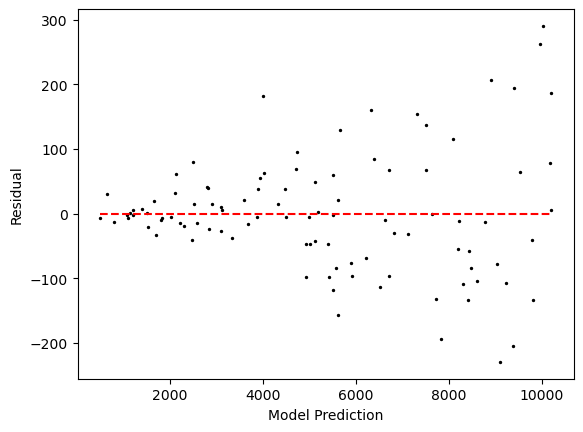

In [29]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# Collinear

In [30]:
#Build the path for the data file
data_path = osp.join(
    osp.curdir,'Data','MMA 860 Assessing and Testing Data File v1.0.xlsx')

#Use the read_excel function to pull data from the 'Sales Data' sheet
data = pd.read_excel(
    data_path,sheet_name='Collinear',index_col='Obs')
data.head()

,Y,Experience,Height,Weight
Obs,,,,
1,450,3,52,58
2,330,3,33,36
3,505,5,37,52
4,254,3,44,52
5,186,2,14,27


In [31]:
train_X = data[['Experience','Height']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ Experience + Height',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     255.0
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           2.36e-39
Time:                        20:31:52   Log-Likelihood:                -540.07
No. Observations:                 100   AIC:                             1086.
Df Residuals:                      97   BIC:                             1094.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9241     16.868      0.055      0.9

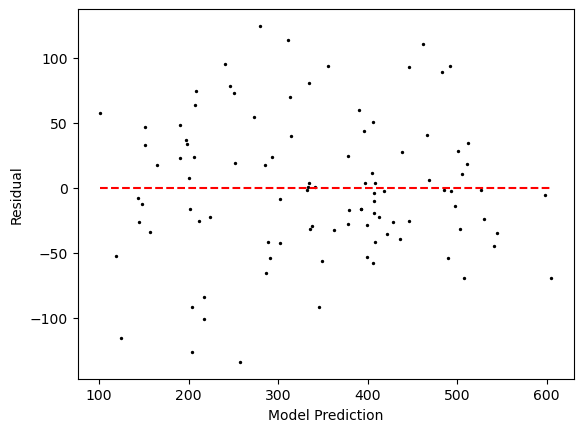

In [32]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# Very broad around line of best fit. This is a shit model.

In [33]:
train_X = data[['Experience','Weight']].values
train_y = data['Y'].values

reg = LinearRegression().fit(train_X, train_y)
model = ols('Y ~ Experience + Weight',data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     217.0
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.55e-36
Time:                        20:36:13   Log-Likelihood:                -546.75
No. Observations:                 100   AIC:                             1100.
Df Residuals:                      97   BIC:                             1107.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.4614     20.496     -0.510      0.6

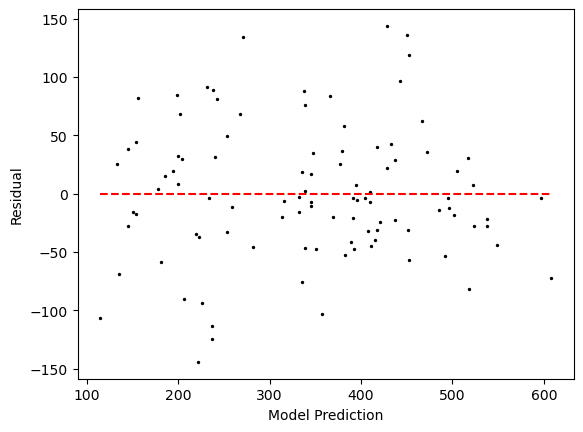

In [34]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# Weight seems to be a better explainer of Y than height along with experience. 